<a href="https://colab.research.google.com/github/chrishg23-jpg/Community-Development-Framework/blob/main/N100sweepY001.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import numpy as np
from scipy.ndimage import laplace

# ---------------------------------------------------------
# Tuned engine parameters
# ---------------------------------------------------------
dt    = 0.01        # small timestep
alpha = 0.05        # weak anti-diffusionw
beta  = 0.10        # stronger damping
lap_scale = 0.1     # Laplacian scaling to prevent blow-up

def gaussian_resonance(N, center=100, width=3.0):
    return np.exp(-((N - center)**2) / (2 * width**2))

# ---------------------------------------------------------
# Initialization
# ---------------------------------------------------------
def initialize_fields(shape=(128,128)):
    S = np.random.normal(0, 0.001, size=shape)   # much smaller noise
    M = np.zeros(shape)
    return S, M

# ---------------------------------------------------------
# Update S field
# ---------------------------------------------------------
def update_S(S, gamma, N):
    lap = laplace(S) * lap_scale

    R = gaussian_resonance(N)

    curvature_term = alpha * R * lap
    damping_term   = -beta * S
    global_term    = -gamma * np.mean(S)

    S_new = S + dt * (curvature_term + damping_term + global_term)

    # soft clipping to prevent runaway
    S_new = np.clip(S_new, -1.0, 1.0)

    return S_new

# ---------------------------------------------------------
# Update memory field
# ---------------------------------------------------------
def update_M(M, S):
    lap = laplace(S) * lap_scale
    return M + dt * np.abs(lap)


In [9]:
def laplacian(S):
    return laplace(S)


In [10]:
import numpy as np
import pandas as pd

# ---------------------------------------------------------
# Sweep parameters
# ---------------------------------------------------------
gamma_values = [0.1, 0.3, 0.5, 1.0, 2.0]
N_values     = [95, 99, 100, 101, 105]

timesteps = 2000            # or your stable late-time horizon
late_window = (1500, 2000)  # adjust to your known stationary regime

results = []

# ---------------------------------------------------------
# Main sweep loop
# ---------------------------------------------------------
for gamma in gamma_values:
    for N in N_values:

        S, M = initialize_fields()          # your existing init
        action_series = []

        for t in range(timesteps):
            S = update_S(S, gamma=gamma, N=N)   # your engine step
            M = update_M(M, S)                  # memory update

            lap = laplacian(S)
            A_t = np.sum(np.abs(lap))
            action_series.append(A_t)

        # Late-time statistics
        A_late = action_series[late_window[0]:late_window[1]]
        mean_A = np.mean(A_late)
        std_A  = np.std(A_late)

        results.append({
            "gamma": gamma,
            "N": N,
            "mean_action": mean_A,
            "std_action": std_A
        })

# ---------------------------------------------------------
# Results table
# ---------------------------------------------------------
df = pd.DataFrame(results)
df


,gamma,N,mean_action,std_action
0,0.1,95,9.029819,1.389457
1,0.1,99,6.552061,1.173839
2,0.1,100,6.389319,1.155692
3,0.1,101,6.582554,1.179404
4,0.1,105,8.990476,1.383512
5,0.3,95,8.969796,1.380246
6,0.3,99,6.600593,1.182233
7,0.3,100,6.409820,1.159355
8,0.3,101,6.642302,1.188997
9,0.3,105,9.079384,1.396357


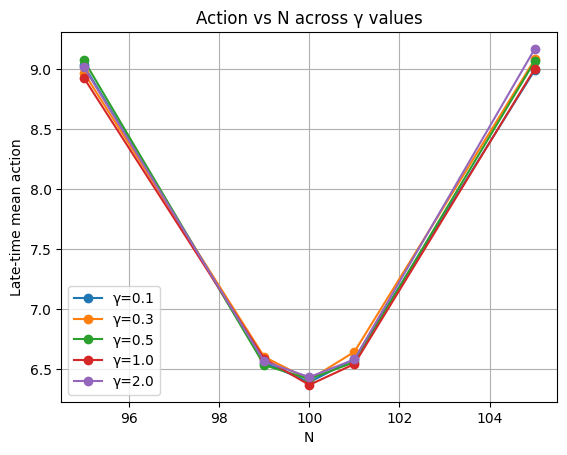

In [11]:
import matplotlib.pyplot as plt

for gamma in gamma_values:
    sub = df[df.gamma == gamma]
    plt.plot(sub.N, sub.mean_action, marker='o', label=f"γ={gamma}")

plt.xlabel("N")
plt.ylabel("Late-time mean action")
plt.title("Action vs N across γ values")
plt.legend()
plt.grid(True)
plt.show()
